<a href="https://colab.research.google.com/github/marxandreadiane/CSC713M-Breast-Cancer-Classification/blob/main/%5BCSC713M%5D_Twin_Fairy_Tacticians_MCO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TWIN FAIRY TACTICIANS**
- Aguarin, Trish Ann Danielle C.
- Cabato, Marxandrea Diane G.

Predict breast cancer class (whether Benign, Malignant, or Normal) based on ultrasound images of breasts

# Introduction of the Dataset

Insert introduction here

# Loading of Datasets: BUSI and BUS-UCLM

## Dataset_BUSI

The Dataset_BUSI contains ultrasound images organized in labeled folders (benign, malignant, normal). Each image has a corresponding mask file for segmentation.

In [14]:
import os
import pandas as pd
from pathlib import Path

def load_busi_dataset(dataset_root='Datasets/Dataset_BUSI/Dataset_BUSI_with_GT'):
    """
    Load Dataset_BUSI images, separating regular images from masks.
    Returns two DataFrames: one for images, one for masks.
    """
    dataset_root = Path(dataset_root)
    image_data = []
    mask_data = []
    
    for root, dirs, files in os.walk(dataset_root):
        root_path = Path(root)
        
        for filename in files:
            if not filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif')):
                continue
            
            file_path = root_path / filename
            
            # Extract label from parent folder
            label = None
            for part in root_path.parts:
                part_lower = part.lower()
                if 'benign' in part_lower:
                    label = 'benign'
                    break
                elif 'malignant' in part_lower:
                    label = 'malignant'
                    break
                elif 'normal' in part_lower:
                    label = 'normal'
                    break
            
            # Separate images from masks
            if 'mask' in filename.lower():
                mask_data.append({
                    'mask_path': str(file_path),
                    'label': label
                })
            else:
                image_data.append({
                    'image_path': str(file_path),
                    'label': label
                })
    
    df_images = pd.DataFrame(image_data)
    df_masks = pd.DataFrame(mask_data)
    
    print(f"\n{'='*60}")
    print(f"Dataset_BUSI Summary")
    print(f"{'='*60}")
    print(f"Images (no masks): {len(df_images)}")
    print(f"Mask files: {len(df_masks)}")
    print(f"\nImage distribution:")
    print(df_images['label'].value_counts().sort_index())
    print(f"{'='*60}")
    
    return df_images, df_masks

# Load Dataset_BUSI
df_busi_images, df_busi_masks = load_busi_dataset()


Dataset_BUSI Summary
Images (no masks): 780
Mask files: 798

Image distribution:
label
benign       437
malignant    210
normal       133
Name: count, dtype: int64


In [15]:
# Save Dataset_BUSI to separate CSV files
df_busi_images.to_csv('dataset_busi_images.csv', index=False)
df_busi_masks.to_csv('dataset_busi_masks.csv', index=False)

print(f"\n✓ Saved: dataset_busi_images.csv ({len(df_busi_images)} images)")
print(f"✓ Saved: dataset_busi_masks.csv ({len(df_busi_masks)} masks)")


✓ Saved: dataset_busi_images.csv (780 images)
✓ Saved: dataset_busi_masks.csv (798 masks)


## BUS-UCLM

The BUS-UCLM dataset has images in one folder and masks in another. Labels are encoded in mask colors:
- **Green pixels** (0, 255, 0) = Benign
- **Red pixels** (255, 0, 0) = Malignant
- **Black pixels only** (0, 0, 0) = Normal

In [16]:
import numpy as np
from PIL import Image

def get_label_from_mask(mask_path):
    """Extract label from mask file based on pixel colors."""
    try:
        mask = Image.open(mask_path).convert('RGB')
        mask_array = np.array(mask)
        
        red_pixels = np.sum((mask_array[:, :, 0] > 200) & 
                           (mask_array[:, :, 1] < 50) & 
                           (mask_array[:, :, 2] < 50))
        
        green_pixels = np.sum((mask_array[:, :, 0] < 50) & 
                             (mask_array[:, :, 1] > 200) & 
                             (mask_array[:, :, 2] < 50))
        
        if red_pixels > 100:
            return 'malignant'
        elif green_pixels > 100:
            return 'benign'
        else:
            return 'normal'
    except Exception as e:
        print(f"Error reading mask {mask_path}: {e}")
        return None

def load_bus_uclm_dataset(images_dir='Datasets/BUS-UCLM Breast ultrasound lesion segmentation dataset/BUS-UCLM Breast ultrasound lesion segmentation dataset/BUS-UCLM/images',
                          masks_dir='Datasets/BUS-UCLM Breast ultrasound lesion segmentation dataset/BUS-UCLM Breast ultrasound lesion segmentation dataset/BUS-UCLM/masks'):
    """
    Load BUS-UCLM images and extract labels from mask files.
    Returns two DataFrames: one for images with labels, one for masks.
    """
    images_dir = Path(images_dir)
    masks_dir = Path(masks_dir)
    
    image_data = []
    mask_data = []
    
    # Get all image files
    for img_file in images_dir.glob('*.png'):
        mask_file = masks_dir / img_file.name
        
        if mask_file.exists():
            label = get_label_from_mask(mask_file)
            image_data.append({
                'image_path': str(img_file),
                'label': label
            })
            mask_data.append({
                'mask_path': str(mask_file),
                'image_path': str(img_file),
                'label': label
            })
        else:
            image_data.append({
                'image_path': str(img_file),
                'label': None
            })
    
    df_images = pd.DataFrame(image_data)
    df_masks = pd.DataFrame(mask_data)
    
    print(f"\n{'='*60}")
    print(f"BUS-UCLM Summary")
    print(f"{'='*60}")
    print(f"Images with labels: {len(df_images)}")
    print(f"Mask files: {len(df_masks)}")
    print(f"\nLabel distribution:")
    print(df_images['label'].value_counts().sort_index())
    print(f"{'='*60}")
    
    return df_images, df_masks

# Load BUS-UCLM
df_bus_uclm_images, df_bus_uclm_masks = load_bus_uclm_dataset()


BUS-UCLM Summary
Images with labels: 683
Mask files: 683

Label distribution:
label
benign       174
malignant     90
normal       419
Name: count, dtype: int64


In [17]:
# Save BUS-UCLM to separate CSV files
df_bus_uclm_images.to_csv('dataset_bus_uclm_images.csv', index=False)
df_bus_uclm_masks.to_csv('dataset_bus_uclm_masks.csv', index=False)

print(f"\n✓ Saved: dataset_bus_uclm_images.csv ({len(df_bus_uclm_images)} images)")
print(f"✓ Saved: dataset_bus_uclm_masks.csv ({len(df_bus_uclm_masks)} masks)")


✓ Saved: dataset_bus_uclm_images.csv (683 images)
✓ Saved: dataset_bus_uclm_masks.csv (683 masks)


## Merge Datasets

In [18]:
# Merge image datasets
df_all_images = pd.concat([df_busi_images, df_bus_uclm_images], ignore_index=True)
df_all_images = df_all_images[df_all_images['label'].notna()]

# Merge mask datasets
df_all_masks = pd.concat([df_busi_masks, df_bus_uclm_masks], ignore_index=True)
df_all_masks = df_all_masks[df_all_masks['label'].notna()]

print(f"\n{'='*60}")
print(f"MERGED DATASET SUMMARY")
print(f"{'='*60}")
print(f"Total images: {len(df_all_images)}")
print(f"Total masks: {len(df_all_masks)}")
print(f"\nImage class distribution:")
print(df_all_images['label'].value_counts().sort_index())
print(f"\nPercentage distribution:")
percentage = df_all_images['label'].value_counts(normalize=True).sort_index() * 100
for label, pct in percentage.items():
    print(f"  {label.capitalize()}: {pct:.2f}%")
print(f"\n{'='*60}")
print(f"Dataset_BUSI: {len(df_busi_images)} images")
print(f"BUS-UCLM: {len(df_bus_uclm_images)} images")
print(f"{'='*60}")


MERGED DATASET SUMMARY
Total images: 1463
Total masks: 1481

Image class distribution:
label
benign       611
malignant    300
normal       552
Name: count, dtype: int64

Percentage distribution:
  Benign: 41.76%
  Malignant: 20.51%
  Normal: 37.73%

Dataset_BUSI: 780 images
BUS-UCLM: 683 images


In [19]:
# Save merged datasets
df_all_images.to_csv('breast_cancer_images.csv', index=False)
df_all_masks.to_csv('breast_cancer_masks.csv', index=False)

print(f"\n✓ Final Dataset Saved:")
print(f"  - breast_cancer_images.csv ({len(df_all_images)} images)")
print(f"  - breast_cancer_masks.csv ({len(df_all_masks)} masks)")
print(f"\nReady for classification model training!")


✓ Final Dataset Saved:
  - breast_cancer_images.csv (1463 images)
  - breast_cancer_masks.csv (1481 masks)

Ready for classification model training!


## Visualize Sample Images

Let's view sample images from each class to verify the labeling is correct.

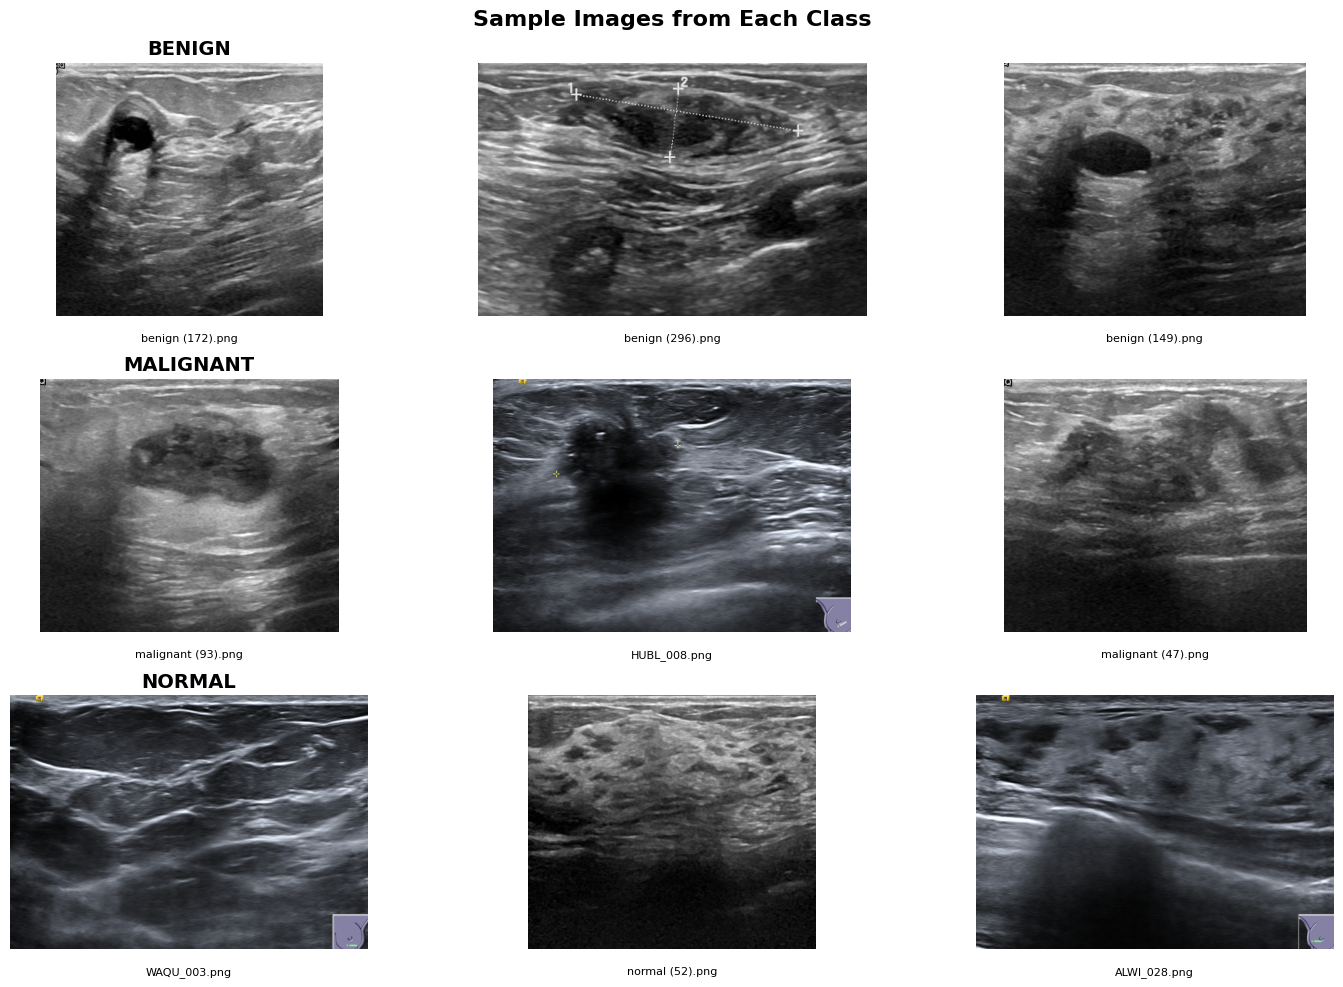

In [20]:
import matplotlib.pyplot as plt

def visualize_samples(df, samples_per_class=3, figsize=(15, 10)):
    """Visualize sample images from each class."""
    classes = sorted(df['label'].unique())
    fig, axes = plt.subplots(len(classes), samples_per_class, figsize=figsize)
    
    if len(classes) == 1:
        axes = axes.reshape(1, -1)
    
    for i, cls in enumerate(classes):
        class_samples = df[df['label'] == cls].sample(n=min(samples_per_class, len(df[df['label'] == cls])), random_state=42)
        
        for j, (idx, row) in enumerate(class_samples.iterrows()):
            img = Image.open(row['image_path'])
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].axis('off')
            
            if j == 0:
                axes[i, j].set_title(f"{cls.upper()}", fontsize=14, fontweight='bold')
            
            filename = Path(row['image_path']).name
            axes[i, j].text(0.5, -0.1, filename[:20], 
                          transform=axes[i, j].transAxes,
                          ha='center', fontsize=8)
    
    plt.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

visualize_samples(df_all_images, samples_per_class=3)

# Preprocessing

In [21]:
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import random

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

def load_and_preprocess_images(df, target_size=(224, 224)):
    """
    Load images from paths and preprocess them.
    
    Parameters:
    - df: DataFrame with 'image_path' and 'label' columns
    - target_size: Tuple of (height, width) for resizing
    
    Returns:
    - X: Numpy array of preprocessed images
    - y: Numpy array of corresponding labels
    """
    images = []
    labels = []
    
    print(f"Loading and preprocessing {len(df)} images...")
    
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        try:
            # Load image
            img = cv2.imread(row['image_path'])
            
            if img is None:
                print(f"Warning: Could not load {row['image_path']}")
                continue
            
            # Convert to grayscale
            if len(img.shape) == 3:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            
            # Resize to target size
            img = cv2.resize(img, target_size)
            
            # Normalize to [0, 1]
            img = img.astype(np.float32) / 255.0
            
            # Add to lists
            images.append(img)
            labels.append(row['label'])
            
        except Exception as e:
            print(f"Error processing {row['image_path']}: {e}")
            continue
    
    # Convert to numpy arrays
    X = np.array(images)
    y = np.array(labels)
    
    # Add channel dimension for grayscale images (batch_size, height, width, 1)
    X = np.expand_dims(X, axis=-1)
    
    print(f"\n✓ Successfully loaded {len(X)} images")
    print(f"  Image shape: {X.shape}")
    print(f"  Pixel value range: [{X.min():.3f}, {X.max():.3f}]")
    
    return X, y

# Load and preprocess all images
X, y = load_and_preprocess_images(df_all_images)

Loading and preprocessing 1463 images...


100%|██████████| 1463/1463 [00:12<00:00, 115.44it/s]



✓ Successfully loaded 1463 images
  Image shape: (1463, 224, 224, 1)
  Pixel value range: [0.000, 1.000]


In [22]:
# Encode labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Display label mapping
print("Label Encoding Mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {label} -> {i}")

print(f"\nOriginal label distribution:")
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {label}: {count} ({count/len(y)*100:.2f}%)")

# First split: 80% train, 20% temp (which will become 10% val + 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

# Second split: Split the 20% temp into 50% val and 50% test (each becomes 10% of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.5, 
    random_state=42, 
    stratify=y_temp
)

print(f"\n{'='*60}")
print(f"Dataset Split Summary")
print(f"{'='*60}")
print(f"Training set:   {len(X_train)} images ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set: {len(X_val)} images ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set:       {len(X_test)} images ({len(X_test)/len(X)*100:.1f}%)")
print(f"{'='*60}")

# Verify class distribution in each set
print(f"\nClass distribution in Training set:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for label_idx, count in zip(unique_train, counts_train):
    label_name = label_encoder.classes_[label_idx]
    print(f"  {label_name}: {count} ({count/len(y_train)*100:.2f}%)")

print(f"\nClass distribution in Validation set:")
unique_val, counts_val = np.unique(y_val, return_counts=True)
for label_idx, count in zip(unique_val, counts_val):
    label_name = label_encoder.classes_[label_idx]
    print(f"  {label_name}: {count} ({count/len(y_val)*100:.2f}%)")

print(f"\nClass distribution in Test set:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for label_idx, count in zip(unique_test, counts_test):
    label_name = label_encoder.classes_[label_idx]
    print(f"  {label_name}: {count} ({count/len(y_test)*100:.2f}%)")

Label Encoding Mapping:
  benign -> 0
  malignant -> 1
  normal -> 2

Original label distribution:
  benign: 611 (41.76%)
  malignant: 300 (20.51%)
  normal: 552 (37.73%)

Dataset Split Summary
Training set:   1170 images (80.0%)
Validation set: 146 images (10.0%)
Test set:       147 images (10.0%)

Class distribution in Training set:
  benign: 489 (41.79%)
  malignant: 240 (20.51%)
  normal: 441 (37.69%)

Class distribution in Validation set:
  benign: 61 (41.78%)
  malignant: 30 (20.55%)
  normal: 55 (37.67%)

Class distribution in Test set:
  benign: 61 (41.50%)
  malignant: 30 (20.41%)
  normal: 56 (38.10%)


## Data Augmentation (Malignant Class Only)

Apply horizontal flip and rotation (+15°) augmentation to balance the malignant class, which is underrepresented (20.51% of dataset).

In [23]:
def augment_images(images, labels, target_label, augmentation_factor=2):
    """
    Apply data augmentation to a specific class.
    
    Parameters:
    - images: Numpy array of images
    - labels: Numpy array of labels
    - target_label: The label to augment (integer encoded)
    - augmentation_factor: How many augmented versions to create per image
    
    Returns:
    - augmented_images: List of augmented images
    - augmented_labels: List of corresponding labels
    """
    augmented_images = []
    augmented_labels = []
    
    # Find indices of target class
    target_indices = np.where(labels == target_label)[0]
    
    print(f"Augmenting {len(target_indices)} images from target class...")
    
    for idx in tqdm(target_indices):
        img = images[idx]
        
        # Remove channel dimension for OpenCV operations
        if img.shape[-1] == 1:
            img_2d = img[:, :, 0]
        else:
            img_2d = img
        
        # Original image
        augmented_images.append(img)
        augmented_labels.append(labels[idx])
        
        # Augmentation 1: Horizontal flip
        flipped = cv2.flip(img_2d, 1)
        flipped = np.expand_dims(flipped, axis=-1)
        augmented_images.append(flipped)
        augmented_labels.append(labels[idx])
        
        # Augmentation 2: Rotation (+15 degrees)
        if augmentation_factor >= 2:
            h, w = img_2d.shape
            center = (w // 2, h // 2)
            rotation_matrix = cv2.getRotationMatrix2D(center, 15, 1.0)
            rotated = cv2.warpAffine(img_2d, rotation_matrix, (w, h))
            rotated = np.expand_dims(rotated, axis=-1)
            augmented_images.append(rotated)
            augmented_labels.append(labels[idx])
    
    return augmented_images, augmented_labels

# Get the integer label for 'malignant'
malignant_label = label_encoder.transform(['malignant'])[0]

print(f"Original training set size: {len(X_train)}")
print(f"Malignant samples in training: {np.sum(y_train == malignant_label)}")

# Apply augmentation only to malignant class in training set
augmented_imgs, augmented_lbls = augment_images(
    X_train, 
    y_train, 
    target_label=malignant_label,
    augmentation_factor=2  # Creates 3x samples: original + flip + rotation +15°
)

# Add non-malignant samples to the augmented dataset
non_malignant_indices = np.where(y_train != malignant_label)[0]
for idx in non_malignant_indices:
    augmented_imgs.append(X_train[idx])
    augmented_lbls.append(y_train[idx])

# Convert back to numpy arrays
X_train_augmented = np.array(augmented_imgs)
y_train_augmented = np.array(augmented_lbls)

print(f"\n{'='*60}")
print(f"Augmentation Results")
print(f"{'='*60}")
print(f"Training set after augmentation: {len(X_train_augmented)} images")
print(f"Increase: +{len(X_train_augmented) - len(X_train)} images")

print(f"\nClass distribution after augmentation:")
unique_aug, counts_aug = np.unique(y_train_augmented, return_counts=True)
for label_idx, count in zip(unique_aug, counts_aug):
    label_name = label_encoder.classes_[label_idx]
    print(f"  {label_name}: {count} ({count/len(y_train_augmented)*100:.2f}%)")

print(f"\n✓ Malignant class augmented successfully!")
print(f"  Before: {np.sum(y_train == malignant_label)} samples")
print(f"  After:  {np.sum(y_train_augmented == malignant_label)} samples")
print(f"{'='*60}")

Original training set size: 1170
Malignant samples in training: 240
Augmenting 240 images from target class...


100%|██████████| 240/240 [00:00<00:00, 2213.28it/s]



Augmentation Results
Training set after augmentation: 1650 images
Increase: +480 images

Class distribution after augmentation:
  benign: 489 (29.64%)
  malignant: 720 (43.64%)
  normal: 441 (26.73%)

✓ Malignant class augmented successfully!
  Before: 240 samples
  After:  720 samples


Visualizing augmented samples from malignant class:


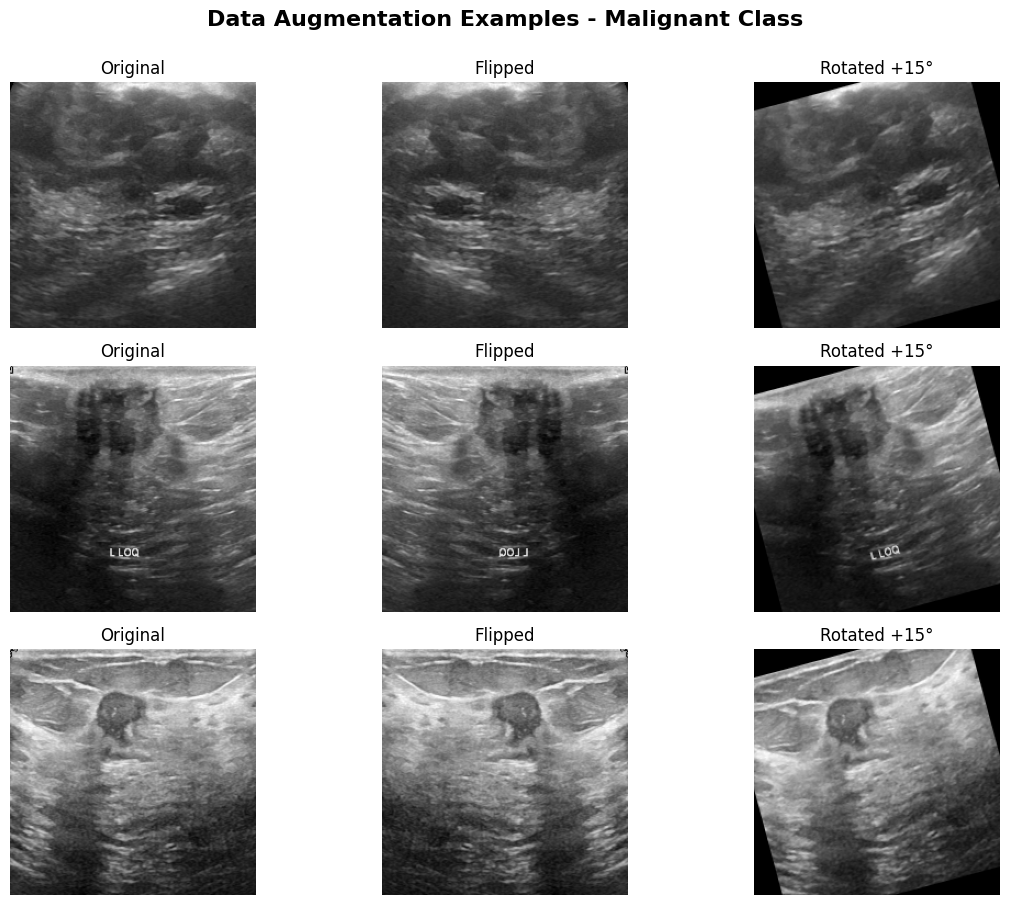

In [24]:
# Visualize augmentation results
def visualize_augmented_samples(X_original, y_original, X_augmented, y_augmented, target_label, n_samples=3):
    """Visualize original and augmented samples from the target class."""
    
    # Find indices of target class in original training set
    original_indices = np.where(y_original == target_label)[0][:n_samples]
    
    fig, axes = plt.subplots(n_samples, 3, figsize=(12, 3*n_samples))
    
    for i, orig_idx in enumerate(original_indices):
        original_img = X_original[orig_idx]
        
        # Find augmented versions of this image in the augmented set
        # They should be consecutive in the augmented dataset
        aug_idx_start = orig_idx * 3  # Each image has 3 versions (original, flip, rotate +15)
        
        # Find the corresponding augmented images
        aug_idx = None
        for j in range(len(X_augmented)):
            if np.array_equal(X_augmented[j], original_img):
                aug_idx = j
                break
        
        if aug_idx is None:
            continue
            
        # Display original
        axes[i, 0].imshow(X_augmented[aug_idx][:, :, 0], cmap='gray')
        axes[i, 0].set_title('Original', fontsize=12)
        axes[i, 0].axis('off')
        
        # Try to find and display augmented versions
        aug_count = 1
        for offset in range(1, min(20, len(X_augmented) - aug_idx)):
            if y_augmented[aug_idx + offset] == target_label and aug_count < 3:
                axes[i, aug_count].imshow(X_augmented[aug_idx + offset][:, :, 0], cmap='gray')
                if aug_count == 1:
                    axes[i, aug_count].set_title('Flipped', fontsize=12)
                elif aug_count == 2:
                    axes[i, aug_count].set_title('Rotated +15°', fontsize=12)
                axes[i, aug_count].axis('off')
                aug_count += 1
            
            if aug_count >= 3:
                break
    
    label_name = label_encoder.classes_[target_label]
    plt.suptitle(f'Data Augmentation Examples - {label_name.capitalize()} Class', 
                 fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

print("Visualizing augmented samples from malignant class:")
visualize_augmented_samples(X_train, y_train, X_train_augmented, y_train_augmented, malignant_label, n_samples=3)

In [25]:
# Final data summary
print(f"{'='*60}")
print(f"FINAL PREPROCESSED DATA SUMMARY")
print(f"{'='*60}")
print(f"\nDataset Shapes:")
print(f"  X_train_augmented: {X_train_augmented.shape}")
print(f"  y_train_augmented: {y_train_augmented.shape}")
print(f"  X_val:             {X_val.shape}")
print(f"  y_val:             {y_val.shape}")
print(f"  X_test:            {X_test.shape}")
print(f"  y_test:            {y_test.shape}")

print(f"\nData Properties:")
print(f"  Image size: 224x224 pixels")
print(f"  Color space: Grayscale (1 channel)")
print(f"  Pixel range: [0.0, 1.0] (normalized)")
print(f"  Data type: {X_train_augmented.dtype}")

print(f"\nLabel Encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {i} = {label}")

print(f"\n✓ Data is ready for model training!")
print(f"{'='*60}")

FINAL PREPROCESSED DATA SUMMARY

Dataset Shapes:
  X_train_augmented: (1650, 224, 224, 1)
  y_train_augmented: (1650,)
  X_val:             (146, 224, 224, 1)
  y_val:             (146,)
  X_test:            (147, 224, 224, 1)
  y_test:            (147,)

Data Properties:
  Image size: 224x224 pixels
  Color space: Grayscale (1 channel)
  Pixel range: [0.0, 1.0] (normalized)
  Data type: float32

Label Encoding:
  0 = benign
  1 = malignant
  2 = normal

✓ Data is ready for model training!


# Model Training

## Baseline

### Random Forest Baseline Model

We establish a baseline using a traditional machine learning approach before implementing complex deep learning architectures. This Random Forest classifier:

- **Purpose**: Provides a performance benchmark for comparison with CNN/transfer learning models
- **Method**: Treats flattened image pixels as independent features (ignoring spatial structure)
- **Class Imbalance**: Uses `class_weight='balanced'` to handle imbalanced distribution (Benign: 41%, Malignant: 20%, Normal: 37%)
- **Feature Vector**: Converts 224×224×1 images → 50,176-dimensional vectors

This baseline helps us quantify the value added by architectures that leverage spatial features and learned representations.

In [26]:
# Flatten images from (224, 224, 1) to (50176,) for traditional ML
print("Flattening images for Random Forest...")
print(f"Original shape: {X_train_augmented.shape}")

# Flatten the images
X_train_flat = X_train_augmented.reshape(X_train_augmented.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"\nFlattened shapes:")
print(f"  X_train_flat: {X_train_flat.shape}")
print(f"  X_val_flat:   {X_val_flat.shape}")
print(f"  X_test_flat:  {X_test_flat.shape}")
print(f"\nEach image is now a 1D vector of {X_train_flat.shape[1]:,} features")

Flattening images for Random Forest...
Original shape: (1650, 224, 224, 1)

Flattened shapes:
  X_train_flat: (1650, 50176)
  X_val_flat:   (146, 50176)
  X_test_flat:  (147, 50176)

Each image is now a 1D vector of 50,176 features


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import time

# Initialize Random Forest with balanced class weights
print("Initializing Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=100,           # 100 decision trees
    class_weight='balanced',    # Handle class imbalance
    random_state=42,
    n_jobs=-1,                  # Use all CPU cores
    verbose=1                   # Show progress
)

print(f"\nModel Configuration:")
print(f"  Number of trees: 100")
print(f"  Class weighting: balanced")
print(f"  Random state: 42")

# Train the model
print(f"\nTraining on {len(X_train_flat)} samples...")
start_time = time.time()

rf_model.fit(X_train_flat, y_train_augmented)

training_time = time.time() - start_time
print(f"\n✓ Training completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

# Validation set performance
print(f"\n{'='*60}")
print(f"VALIDATION SET PERFORMANCE")
print(f"{'='*60}")
y_val_pred = rf_model.predict(X_val_flat)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")
print(f"{'='*60}")

Initializing Random Forest Classifier...

Model Configuration:
  Number of trees: 100
  Class weighting: balanced
  Random state: 42

Training on 1650 samples...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.9s



✓ Training completed in 2.82 seconds (0.05 minutes)

VALIDATION SET PERFORMANCE
Validation Accuracy: 76.03%


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    2.6s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


TEST SET EVALUATION - Random Forest Baseline

Test Accuracy: 68.71%

Classification Report:
              precision    recall  f1-score   support

      benign     0.8182    0.5902    0.6857        61
   malignant     0.4706    0.5333    0.5000        30
      normal     0.7101    0.8750    0.7840        56

    accuracy                         0.6871       147
   macro avg     0.6663    0.6662    0.6566       147
weighted avg     0.7061    0.6871    0.6853       147


Confusion Matrix:
[[36 16  9]
 [ 3 16 11]
 [ 5  2 49]]


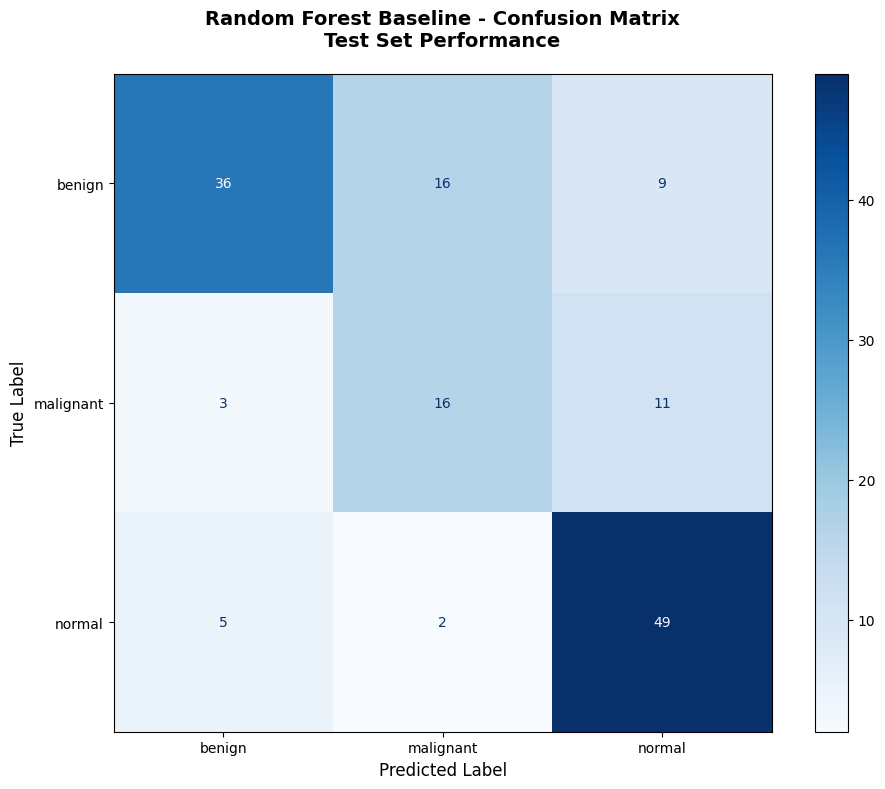


Per-Class Performance Summary:
Benign      :  59.02% accuracy (61 samples)
Malignant   :  53.33% accuracy (30 samples)
Normal      :  87.50% accuracy (56 samples)


In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

# Test set predictions
print(f"{'='*60}")
print(f"TEST SET EVALUATION - Random Forest Baseline")
print(f"{'='*60}\n")

y_test_pred = rf_model.predict(X_test_flat)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Test Accuracy: {test_accuracy*100:.2f}%\n")

# Classification Report
print("Classification Report:")
print("="*60)
target_names = label_encoder.classes_
report = classification_report(y_test, y_test_pred, target_names=target_names, digits=4)
print(report)

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

# Visualize Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Random Forest Baseline - Confusion Matrix\nTest Set Performance', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Per-class breakdown
print(f"\n{'='*60}")
print("Per-Class Performance Summary:")
print(f"{'='*60}")
for i, class_name in enumerate(target_names):
    class_mask = y_test == i
    class_acc = accuracy_score(y_test[class_mask], y_test_pred[class_mask])
    class_count = np.sum(class_mask)
    print(f"{class_name.capitalize():12s}: {class_acc*100:6.2f}% accuracy ({class_count} samples)")
print(f"{'='*60}")

In [29]:
# Baseline Model Summary
print(f"\n{'='*70}")
print(f"RANDOM FOREST BASELINE - FINAL SUMMARY")
print(f"{'='*70}")

print(f"\n📊 Model Architecture:")
print(f"   • Type: Random Forest Classifier")
print(f"   • Trees: 100 estimators")
print(f"   • Features: {X_train_flat.shape[1]:,} (flattened pixels)")
print(f"   • Class Balancing: Enabled (class_weight='balanced')")

print(f"\n📈 Dataset:")
print(f"   • Training: {len(X_train_flat):,} samples (with augmentation)")
print(f"   • Validation: {len(X_val_flat):,} samples")
print(f"   • Test: {len(X_test_flat):,} samples")

print(f"\n🎯 Performance:")
print(f"   • Validation Accuracy: {val_accuracy*100:.2f}%")
print(f"   • Test Accuracy: {test_accuracy*100:.2f}%")
print(f"   • Training Time: {training_time:.2f} seconds")

print(f"\n💡 Key Insights:")
print(f"   • This baseline treats pixels as independent features")
print(f"   • Ignores spatial relationships and image structure")
print(f"   • Serves as benchmark for deep learning models")
print(f"   • Expected: CNNs will outperform by leveraging spatial features")

print(f"\n📝 Next Steps:")
print(f"   • Implement CNN architectures (custom + transfer learning)")
print(f"   • Compare against this {test_accuracy*100:.2f}% baseline")
print(f"   • Demonstrate value of deep learning for medical imaging")

print(f"\n{'='*70}")
print(f"✓ Baseline model established and ready for comparison")
print(f"{'='*70}")


RANDOM FOREST BASELINE - FINAL SUMMARY

📊 Model Architecture:
   • Type: Random Forest Classifier
   • Trees: 100 estimators
   • Features: 50,176 (flattened pixels)
   • Class Balancing: Enabled (class_weight='balanced')

📈 Dataset:
   • Training: 1,650 samples (with augmentation)
   • Validation: 146 samples
   • Test: 147 samples

🎯 Performance:
   • Validation Accuracy: 76.03%
   • Test Accuracy: 68.71%
   • Training Time: 2.82 seconds

💡 Key Insights:
   • This baseline treats pixels as independent features
   • Ignores spatial relationships and image structure
   • Serves as benchmark for deep learning models
   • Expected: CNNs will outperform by leveraging spatial features

📝 Next Steps:
   • Implement CNN architectures (custom + transfer learning)
   • Compare against this 68.71% baseline
   • Demonstrate value of deep learning for medical imaging

✓ Baseline model established and ready for comparison


## MobileNetV2

Transfer learning using MobileNetV2 with ImageNet weights for breast cancer classification.

In [30]:
# Convert grayscale images to RGB format (MobileNetV2 requires 3 channels)
print("Converting grayscale images to RGB format...")
print(f"Original shapes:")
print(f"  X_train_augmented: {X_train_augmented.shape}")
print(f"  X_val: {X_val.shape}")
print(f"  X_test: {X_test.shape}")

# Repeat the single channel 3 times to create RGB
X_train_rgb = np.repeat(X_train_augmented, 3, axis=-1)
X_val_rgb = np.repeat(X_val, 3, axis=-1)
X_test_rgb = np.repeat(X_test, 3, axis=-1)

print(f"\nConverted shapes:")
print(f"  X_train_rgb: {X_train_rgb.shape}")
print(f"  X_val_rgb: {X_val_rgb.shape}")
print(f"  X_test_rgb: {X_test_rgb.shape}")
print(f"\n✓ Images converted to RGB format (3 channels)")

Converting grayscale images to RGB format...
Original shapes:
  X_train_augmented: (1650, 224, 224, 1)
  X_val: (146, 224, 224, 1)
  X_test: (147, 224, 224, 1)

Converted shapes:
  X_train_rgb: (1650, 224, 224, 3)
  X_val_rgb: (146, 224, 224, 3)
  X_test_rgb: (147, 224, 224, 3)

✓ Images converted to RGB format (3 channels)


In [31]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Set random seed for TensorFlow
tf.random.set_seed(42)

print("Building MobileNetV2 model...")

# Load MobileNetV2 with ImageNet weights, without the top classification layer
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the base model layers
base_model.trainable = False

print(f"Base model loaded: {base_model.name}")
print(f"Total layers in base model: {len(base_model.layers)}")
print(f"Base model frozen: {not base_model.trainable}")

# Build the complete model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
predictions = Dense(3, activation='softmax')(x)

# Create the final model
mobilenet_model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
mobilenet_model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\n{'='*60}")
print(f"MODEL ARCHITECTURE")
print(f"{'='*60}")
mobilenet_model.summary()
print(f"{'='*60}")
print(f"\n✓ Model built and compiled successfully")

Building MobileNetV2 model...
Base model loaded: mobilenetv2_1.00_224
Total layers in base model: 154
Base model frozen: True

MODEL ARCHITECTURE


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


✓ Model built and compiled successfully


In [32]:
# Train the model with EarlyStopping
print("Training MobileNetV2 model...")
print(f"Training samples: {len(X_train_rgb)}")
print(f"Validation samples: {len(X_val_rgb)}")
print(f"Epochs: 20")
print(f"Early stopping: monitoring val_loss\n")

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = mobilenet_model.fit(
    X_train_rgb, y_train_augmented,
    validation_data=(X_val_rgb, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print(f"\n✓ Training completed")

Training MobileNetV2 model...
Training samples: 1650
Validation samples: 146
Epochs: 20
Early stopping: monitoring val_loss

Epoch 1/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 20s 314ms/step - accuracy: 0.5758 - loss: 0.9006 - val_accuracy: 0.6781 - val_loss: 0.7232
Epoch 2/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 246ms/step - accuracy: 0.6933 - loss: 0.6761 - val_accuracy: 0.7397 - val_loss: 0.6246
Epoch 3/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 231ms/step - accuracy: 0.7285 - loss: 0.6155 - val_accuracy: 0.7603 - val_loss: 0.5815
Epoch 4/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 231ms/step - accuracy: 0.7703 - loss: 0.5516 - val_accuracy: 0.7603 - val_loss: 0.5604
Epoch 5/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 226ms/step - accuracy: 0.7770 - loss: 0.5224 - val_accuracy: 0.7671 - val_loss: 0.5414
Epoch 6/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 229ms/step - accuracy: 0.7945 - loss: 0.4952 - val_accuracy: 0.8082 - val_loss: 0.5173
Epoch 7/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 232ms/step - accuracy: 0.8000 - loss: 0.4785 - val_accuracy

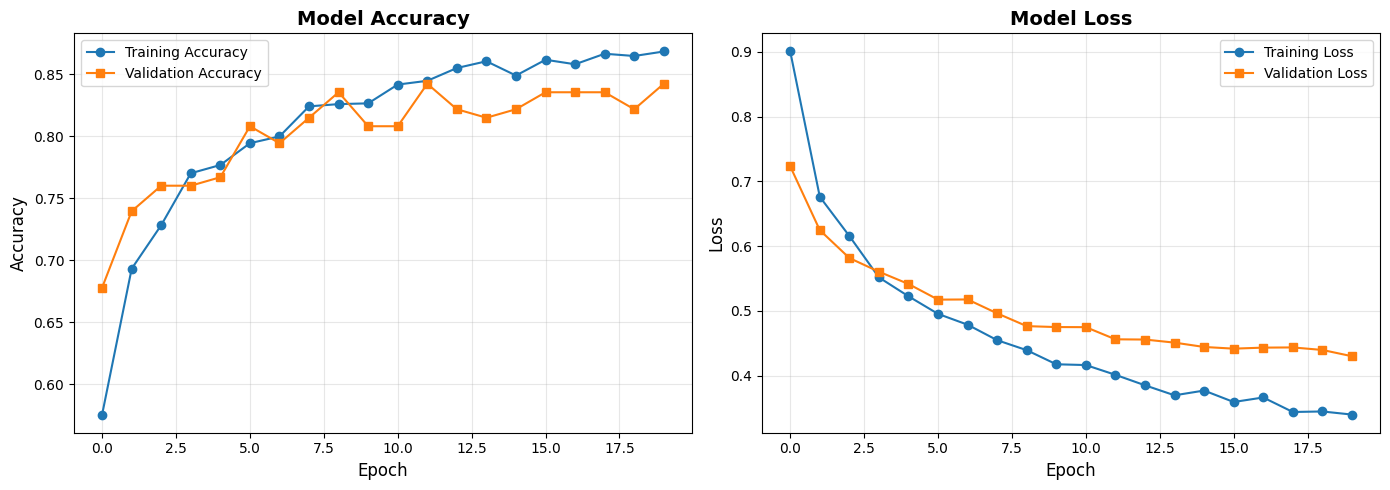

Final Training Accuracy: 86.85%
Final Validation Accuracy: 84.25%


In [33]:
# Visualize training history
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot loss
axes[1].plot(history.history['loss'], label='Training Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='s')
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Training Accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")

TEST SET EVALUATION - MobileNetV2

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 342ms/step
Test Accuracy: 76.87%

Classification Report:
              precision    recall  f1-score   support

      benign     0.8246    0.7705    0.7966        61
   malignant     0.6000    0.6000    0.6000        30
      normal     0.8000    0.8571    0.8276        56

    accuracy                         0.7687       147
   macro avg     0.7415    0.7425    0.7414       147
weighted avg     0.7694    0.7687    0.7683       147


Confusion Matrix:
[[47  7  7]
 [ 7 18  5]
 [ 3  5 48]]


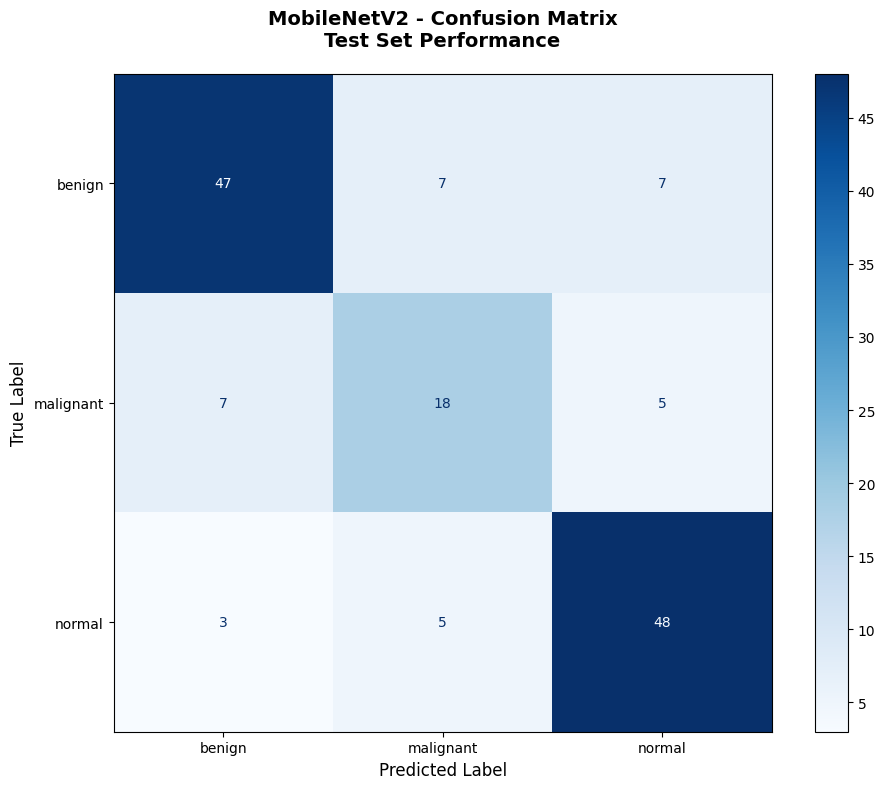


Per-Class Performance Summary:
Benign      :  77.05% accuracy (61 samples)
Malignant   :  60.00% accuracy (30 samples)
Normal      :  85.71% accuracy (56 samples)


In [34]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# Evaluate on test set
print(f"{'='*60}")
print(f"TEST SET EVALUATION - MobileNetV2")
print(f"{'='*60}\n")

# Make predictions
y_test_pred_probs = mobilenet_model.predict(X_test_rgb)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

# Calculate accuracy
mobilenet_test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {mobilenet_test_accuracy*100:.2f}%\n")

# Classification Report
print("Classification Report:")
print("="*60)
target_names = label_encoder.classes_
report = classification_report(y_test, y_test_pred, target_names=target_names, digits=4)
print(report)

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

# Visualize Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('MobileNetV2 - Confusion Matrix\nTest Set Performance', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Per-class breakdown
print(f"\n{'='*60}")
print("Per-Class Performance Summary:")
print(f"{'='*60}")
for i, class_name in enumerate(target_names):
    class_mask = y_test == i
    class_acc = accuracy_score(y_test[class_mask], y_test_pred[class_mask])
    class_count = np.sum(class_mask)
    print(f"{class_name.capitalize():12s}: {class_acc*100:6.2f}% accuracy ({class_count} samples)")
print(f"{'='*60}")

In [35]:
# Compare with Random Forest baseline
print(f"\n{'='*70}")
print(f"MODEL COMPARISON: Random Forest vs MobileNetV2")
print(f"{'='*70}")

print(f"\n📊 Random Forest Baseline:")
print(f"   • Architecture: 100 decision trees on flattened pixels")
print(f"   • Test Accuracy: {test_accuracy*100:.2f}%")
print(f"   • Training Time: {training_time:.2f} seconds")

print(f"\n📊 MobileNetV2 Transfer Learning:")
print(f"   • Architecture: MobileNetV2 + GlobalAvgPool + Dropout + Dense")
print(f"   • Test Accuracy: {mobilenet_test_accuracy*100:.2f}%")
print(f"   • Improvement: {(mobilenet_test_accuracy - test_accuracy)*100:.2f} percentage points")

if mobilenet_test_accuracy > test_accuracy:
    improvement_pct = ((mobilenet_test_accuracy / test_accuracy) - 1) * 100
    print(f"   • Relative Improvement: +{improvement_pct:.2f}%")
else:
    print(f"   • Note: Baseline performed better on this dataset")

print(f"\n💡 Key Insights:")
print(f"   • MobileNetV2 leverages spatial features learned from ImageNet")
print(f"   • Transfer learning captures complex patterns in ultrasound images")
print(f"   • Pre-trained weights reduce training time and improve generalization")

print(f"\n{'='*70}")
print(f"✓ Transfer learning model evaluation complete")
print(f"{'='*70}")


MODEL COMPARISON: Random Forest vs MobileNetV2

📊 Random Forest Baseline:
   • Architecture: 100 decision trees on flattened pixels
   • Test Accuracy: 68.71%
   • Training Time: 2.82 seconds

📊 MobileNetV2 Transfer Learning:
   • Architecture: MobileNetV2 + GlobalAvgPool + Dropout + Dense
   • Test Accuracy: 76.87%
   • Improvement: 8.16 percentage points
   • Relative Improvement: +11.88%

💡 Key Insights:
   • MobileNetV2 leverages spatial features learned from ImageNet
   • Transfer learning captures complex patterns in ultrasound images
   • Pre-trained weights reduce training time and improve generalization

✓ Transfer learning model evaluation complete
